## Load the Cleaned Dataset

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/cleaned_demand_2009_2025.csv",
    parse_dates = [0],
    index_col = 0
)

df.head()

,demand,demand_diff
timestamp,,
2009-01-01 00:00:00,33939.0,NaN
2009-01-01 00:30:00,34072.0,133.0
2009-01-01 01:00:00,33615.0,-457.0
2009-01-01 01:30:00,32526.0,-1089.0
2009-01-01 02:00:00,31877.0,-649.0


## Creat Lag features

In [4]:
# Previous half hour
df["lag_1"] = df["demand"].shift(1)

# Same time previous day
df["lag_48"] = df["demand"].shift(48)

df[["demand", "lag_1", "lag_48"]].head(60)

,demand,lag_1,lag_48
timestamp,,,
2009-01-01 00:00:00,33939.0,NaN,NaN
2009-01-01 00:30:00,34072.0,33939.0,NaN
2009-01-01 01:00:00,33615.0,34072.0,NaN
2009-01-01 01:30:00,32526.0,33615.0,NaN
2009-01-01 02:00:00,31877.0,32526.0,NaN
2009-01-01 02:30:00,31604.0,31877.0,NaN
2009-01-01 03:00:00,30486.0,31604.0,NaN
2009-01-01 03:30:00,29390.0,30486.0,NaN
2009-01-01 04:00:00,28452.0,29390.0,NaN


## Create Rolling Statistics

In [5]:
# Rolling mean (daily window)
df["rolling_mean_48"] = df["demand"].rolling(window=48).mean()

df[["demand", "rolling_mean_48"]].head(100)


,demand,rolling_mean_48
timestamp,,
2009-01-01 00:00:00,33939.0,NaN
2009-01-01 00:30:00,34072.0,NaN
2009-01-01 01:00:00,33615.0,NaN
2009-01-01 01:30:00,32526.0,NaN
2009-01-01 02:00:00,31877.0,NaN
...,...,...
2009-01-02 23:30:00,32309.0,36087.083333
2009-01-03 00:00:00,32841.0,36132.541667
2009-01-03 00:30:00,32389.0,36171.770833


## Extract Date & Time Components

In [6]:
# Critical features for XGBoost and LSTM
dt_idx = pd.DatetimeIndex(df.index)

df["hour"] = dt_idx.hour
df["day_of_week"] = dt_idx.dayofweek
df["month"] = dt_idx.month

df[["hour", "day_of_week", "month"]].head()


,hour,day_of_week,month
timestamp,,,
2009-01-01 00:00:00,0,3,1
2009-01-01 00:30:00,0,3,1
2009-01-01 01:00:00,1,3,1
2009-01-01 01:30:00,1,3,1
2009-01-01 02:00:00,2,3,1


## Drop rows with NaNs (Created by Lags)

In [7]:
df_fe = df.dropna()

df_fe.isna().sum()

demand             0
demand_diff        0
lag_1              0
lag_48             0
rolling_mean_48    0
hour               0
day_of_week        0
month              0
dtype: int64

## Correlation Analysis

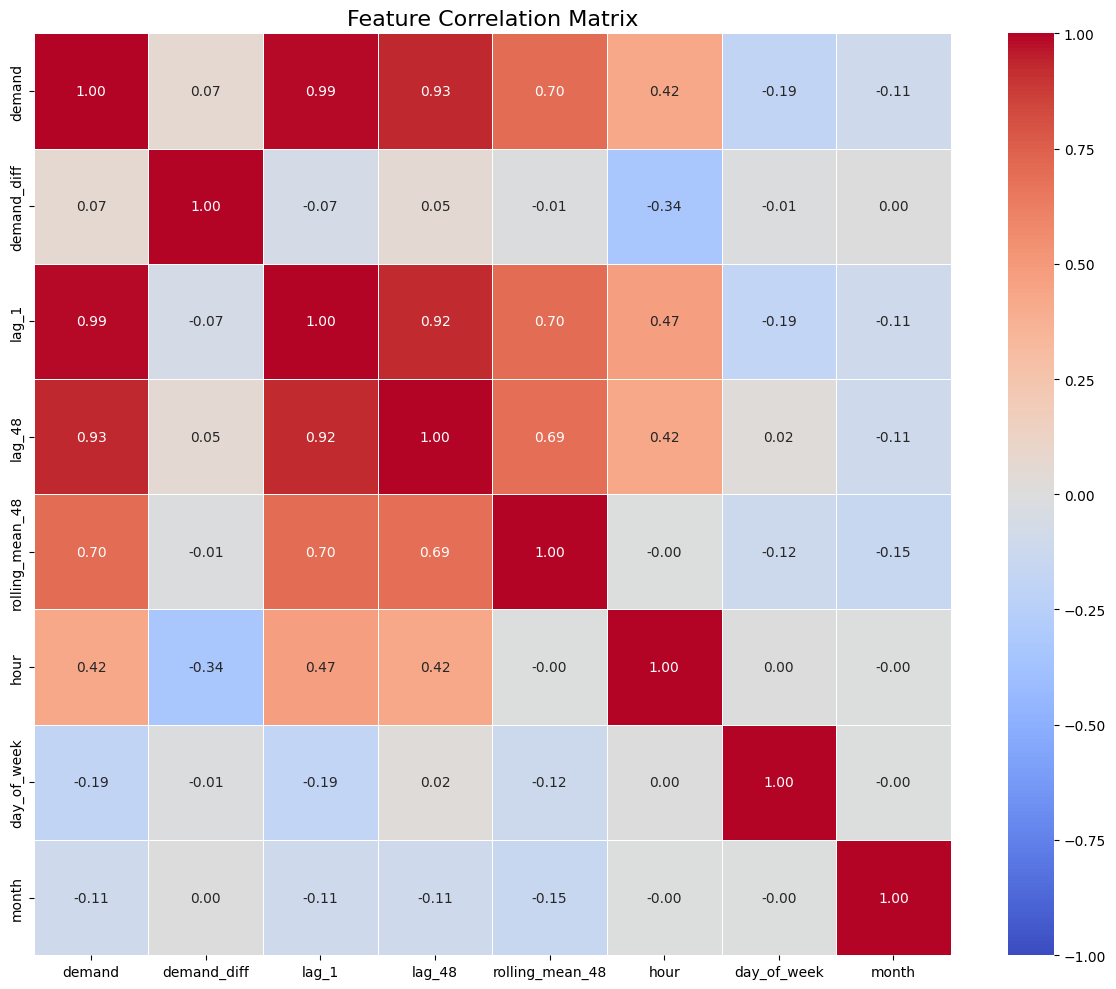

In [8]:
# Generate the correlation matrix
corr_matrix = df_fe.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()

# Save the plot for the final report
plt.savefig('../results/correlation_matrix.png')
plt.show()

## Save Feature-Engineered Dataset

In [11]:
# Save the fULL dataset 
# This file will be the input for BOTH XGBoost and LSTM later.
df_fe.to_csv("../data/processed/feature_engineered_unscaled.csv")

print("Feature engineering complete.")
print(f"Shape: {df_fe.shape}")

Feature engineering complete.
Shape: (282096, 8)
